# 02 - Feature Engineering
**IS5126 Cross-Regional PD Model Transferability Study**

This notebook covers:
1. Load cleaned data from EDA
2. Handle multicollinearity (drop redundant features)
3. Missing value imputation
4. Derived ratio features
5. Categorical encoding (WOE + target encoding)
6. Hybrid emp_title classification (Rule-based + LLM)
7. Feature selection (IV analysis)
8. Export modeling-ready dataset

## 0. Setup

In [91]:
!pip install -q category_encoders shap lightgbm xgboost openai

In [92]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re
import json
import warnings
from scipy import stats

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 80)
pd.set_option('display.float_format', '{:.3f}'.format)

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

COLORS = {
    'primary': '#1F4E79',
    'accent': '#2E86AB',
    'good': '#28A745',
    'bad': '#DC3545',
    'neutral': '#6C757D',
}

os.makedirs('figures', exist_ok=True)
os.makedirs('data/processed', exist_ok=True)

print('Setup complete!')

Setup complete!


## 1. Load Data

In [93]:
from google.colab import drive
drive.mount('/content/drive')

DRIVE_DIR = '/content/drive/MyDrive/is5126'

df = pd.read_parquet(f'{DRIVE_DIR}/data/processed/lending_club_cleaned.parquet')
print(f'Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Default rate: {df["default"].mean()*100:.2f}%')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded: 1,366,817 rows x 90 columns
Default rate: 21.22%


## 2. Handle Multicollinearity

From EDA we found 26 pairs with |r| > 0.8. We drop the less useful one from each pair.

In [94]:
multicollinear_drops = [
    # FICO: keep fico_score, drop raw range endpoints
    'fico_range_low', 'fico_range_high',
    # open_acc vs num_sats (r=0.999): keep open_acc
    'num_sats',
    # num_actv_rev_tl vs num_rev_tl_bal_gt_0 (r=0.982)
    'num_rev_tl_bal_gt_0',
    # tot_cur_bal cluster: keep tot_cur_bal as representative
    'tot_hi_cred_lim', 'total_il_high_credit_limit',
    # bc_open_to_buy correlates with total_bc_limit
    'bc_open_to_buy', 'total_bc_limit',
    # keep num_rev_accts, drop num_op_rev_tl
    'num_op_rev_tl',
    # total_bal_ex_mort ~ tot_cur_bal
    'total_bal_ex_mort',
    # String originals replaced by numeric versions
    'emp_length', 'earliest_cr_line',
]

existing_drops = [c for c in multicollinear_drops if c in df.columns]
df = df.drop(columns=existing_drops)
print(f'Dropped {len(existing_drops)} multicollinear/redundant features')
print(f'Remaining: {df.shape[1]} columns')

Dropped 12 multicollinear/redundant features
Remaining: 78 columns


In [95]:
# Verify remaining high correlations
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != 'default']
corr_matrix = df[numeric_cols].corr()

remaining_high = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.8:
            remaining_high.append((
                corr_matrix.columns[i], corr_matrix.columns[j],
                round(corr_matrix.iloc[i, j], 3)
            ))

print(f'Remaining pairs with |r| > 0.8: {len(remaining_high)}')
for f1, f2, r in remaining_high:
    print(f'  {f1} <-> {f2}: {r}')
if remaining_high:
    print('\nNote: Some remaining correlations are expected (e.g., loan_amnt and installment).')
    print('Tree-based models handle moderate collinearity well.')

Remaining pairs with |r| > 0.8: 13
  loan_amnt <-> installment: 0.953
  mths_since_last_delinq <-> mths_since_recent_revol_delinq: 0.866
  revol_bal <-> total_rev_hi_lim: 0.81
  revol_util <-> bc_util: 0.855
  last_fico_range_high <-> last_fico_range_low: 0.829
  tot_cur_bal <-> avg_cur_bal: 0.835
  open_rv_12m <-> num_tl_op_past_12m: 0.838
  open_rv_24m <-> acc_open_past_24mths: 0.844
  bc_util <-> percent_bc_gt_75: 0.845
  mo_sin_old_rev_tl_op <-> credit_history_months: 0.907
  num_actv_bc_tl <-> num_actv_rev_tl: 0.808
  num_actv_bc_tl <-> num_bc_sats: 0.83
  num_bc_tl <-> num_rev_accts: 0.838

Note: Some remaining correlations are expected (e.g., loan_amnt and installment).
Tree-based models handle moderate collinearity well.


## 3. Missing Value Imputation

Strategy:
- **Numeric:** median imputation + missing indicator flag (EDA showed MAR patterns)
- **Categorical:** fill with 'Unknown'

In [96]:
numeric_features = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_features = [c for c in numeric_features if c != 'default']
categorical_features = df.select_dtypes(include=['object']).columns.tolist()

print(f'Numeric features: {len(numeric_features)}')
print(f'Categorical features: {len(categorical_features)}')
print(f'  Categorical: {categorical_features}')

Numeric features: 66
Categorical features: 11
  Categorical: ['grade', 'sub_grade', 'emp_title', 'home_ownership', 'verification_status', 'pymnt_plan', 'purpose', 'addr_state', 'initial_list_status', 'application_type', 'disbursement_method']


In [97]:
# Missing indicator flags for features with > 1% missing
missing_rates = df[numeric_features].isnull().mean()
features_needing_flag = missing_rates[missing_rates > 0.01].index.tolist()

print(f'Adding missing indicator flags for {len(features_needing_flag)} features:')
for col in features_needing_flag:
    flag_name = f'{col}_missing'
    df[flag_name] = df[col].isnull().astype(int)
    print(f'  {flag_name}: {df[flag_name].mean()*100:.1f}% = 1')

Adding missing indicator flags for 43 features:
  mths_since_last_delinq_missing: 50.4% = 1
  tot_coll_amt_missing: 4.9% = 1
  tot_cur_bal_missing: 4.9% = 1
  open_acc_6m_missing: 59.2% = 1
  open_act_il_missing: 59.2% = 1
  open_il_12m_missing: 59.2% = 1
  open_il_24m_missing: 59.2% = 1
  mths_since_rcnt_il_missing: 60.3% = 1
  total_bal_il_missing: 59.2% = 1
  il_util_missing: 64.7% = 1
  open_rv_12m_missing: 59.2% = 1
  open_rv_24m_missing: 59.2% = 1
  max_bal_bc_missing: 59.2% = 1
  all_util_missing: 59.2% = 1
  total_rev_hi_lim_missing: 4.9% = 1
  inq_fi_missing: 59.2% = 1
  total_cu_tl_missing: 59.2% = 1
  inq_last_12m_missing: 59.2% = 1
  acc_open_past_24mths_missing: 3.5% = 1
  avg_cur_bal_missing: 4.9% = 1
  bc_util_missing: 4.6% = 1
  mo_sin_old_il_acct_missing: 7.8% = 1
  mo_sin_old_rev_tl_op_missing: 4.9% = 1
  mo_sin_rcnt_rev_tl_op_missing: 4.9% = 1
  mo_sin_rcnt_tl_missing: 4.9% = 1
  mort_acc_missing: 3.5% = 1
  mths_since_recent_bc_missing: 4.4% = 1
  mths_since_recent_

In [98]:
# Impute
impute_values = {}
for col in numeric_features:
    if df[col].isnull().any():
        median_val = df[col].median()
        impute_values[col] = median_val
        df[col] = df[col].fillna(median_val)

print(f'Imputed {len(impute_values)} numeric features with median')

for col in categorical_features:
    if df[col].isnull().any():
        null_pct = df[col].isnull().mean() * 100
        df[col] = df[col].fillna('Unknown')
        print(f'Filled {col} nulls with "Unknown" ({null_pct:.1f}%)')

remaining_nulls = df.isnull().sum().sum()
print(f'\nRemaining null values: {remaining_nulls}')
assert remaining_nulls == 0, 'Still have nulls!'

Imputed 50 numeric features with median
Filled emp_title nulls with "Unknown" (6.4%)

Remaining null values: 0


In [99]:
# Save imputation values for Phase 3 transfer
impute_record = {
    'numeric_medians': {k: float(v) for k, v in impute_values.items()},
    'categorical_fill': 'Unknown'
}
with open(f'{DRIVE_DIR}/data/processed/imputation_values.json', 'w') as f:
    json.dump(impute_record, f, indent=2)
print('Saved imputation values for Phase 3')

Saved imputation values for Phase 3


## 4. Derived Ratio Features

In [100]:
df['monthly_inc'] = df['annual_inc'] / 12
df['installment_to_income'] = df['installment'] / (df['monthly_inc'] + 1)
df['loan_to_income'] = df['loan_amnt'] / (df['annual_inc'] + 1)

if 'tot_cur_bal' in df.columns:
    df['revol_to_total_bal'] = df['revol_bal'] / (df['tot_cur_bal'] + 1)
    df['avg_account_bal'] = df['tot_cur_bal'] / (df['total_acc'] + 1)

df['delinq_per_year'] = df['delinq_2yrs'] / (df['credit_history_months'] / 12 + 1)
df['inq_per_open_acc'] = df['inq_last_6mths'] / (df['open_acc'] + 1)
df['revol_bal_to_income'] = df['revol_bal'] / (df['annual_inc'] + 1)

if 'acc_open_past_24mths' in df.columns:
    df['new_acc_rate'] = df['acc_open_past_24mths'] / (df['total_acc'] + 1)

df['is_long_term'] = (df['term'] == 60).astype(int)

new_features = ['monthly_inc', 'installment_to_income', 'loan_to_income',
                'revol_to_total_bal', 'avg_account_bal', 'delinq_per_year',
                'inq_per_open_acc', 'revol_bal_to_income', 'new_acc_rate', 'is_long_term']
new_features = [f for f in new_features if f in df.columns]

print(f'Created {len(new_features)} derived features:\n')
for feat in new_features:
    corr = df[feat].corr(df['default'])
    mean_def = df[df['default']==1][feat].mean()
    mean_non = df[df['default']==0][feat].mean()
    print(f'  {feat:30s} | corr={corr:+.4f} | non-def={mean_non:.4f} | def={mean_def:.4f}')

Created 10 derived features:

  monthly_inc                    | corr=-0.0396 | non-def=6475.4955 | def=5907.6294
  installment_to_income          | corr=+0.0027 | non-def=0.2155 | def=0.2829
  loan_to_income                 | corr=+0.0021 | non-def=4.8368 | def=6.6227
  revol_to_total_bal             | corr=+0.0356 | non-def=0.2574 | def=0.2821
  avg_account_bal                | corr=-0.0607 | non-def=5709.9556 | def=4770.0891
  delinq_per_year                | corr=+0.0267 | non-def=0.0153 | def=0.0183
  inq_per_open_acc               | corr=+0.0513 | non-def=0.0550 | def=0.0664
  revol_bal_to_income            | corr=+0.0001 | non-def=4.6533 | def=4.8226
  new_acc_rate                   | corr=+0.1128 | non-def=0.1905 | def=0.2274
  is_long_term                   | corr=+0.1813 | non-def=0.2036 | def=0.3941


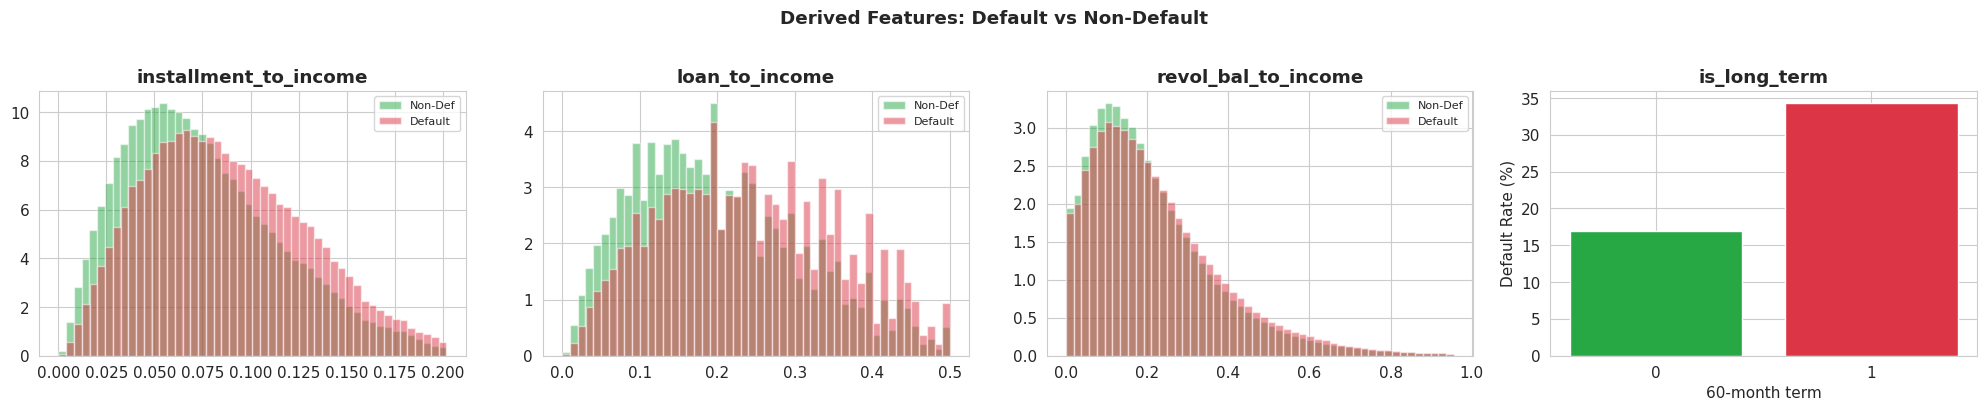

In [101]:
top_derived = ['installment_to_income', 'loan_to_income', 'revol_bal_to_income', 'is_long_term']
top_derived = [f for f in top_derived if f in df.columns]

fig, axes = plt.subplots(1, len(top_derived), figsize=(5 * len(top_derived), 4))
if len(top_derived) == 1: axes = [axes]

for ax, feat in zip(axes, top_derived):
    if feat == 'is_long_term':
        rates = df.groupby(feat)['default'].mean() * 100
        ax.bar(rates.index.astype(str), rates.values, color=[COLORS['good'], COLORS['bad']])
        ax.set_ylabel('Default Rate (%)')
        ax.set_xlabel('60-month term')
    else:
        upper = df[feat].quantile(0.99)
        plot_df = df[df[feat] <= upper]
        for label, color, name in [(0, COLORS['good'], 'Non-Def'), (1, COLORS['bad'], 'Default')]:
            subset = plot_df[plot_df['default'] == label][feat]
            ax.hist(subset, bins=50, alpha=0.5, color=color, density=True, label=name)
        ax.legend(fontsize=8)
    ax.set_title(feat, fontweight='bold')

plt.suptitle('Derived Features: Default vs Non-Default', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('figures/08_derived_features.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Categorical Encoding (WOE)

In [102]:
# Ordinal encoding for grade
grade_map = {'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5, 'F': 6, 'G': 7}
df['grade_num'] = df['grade'].map(grade_map)

sub_grades = sorted(df['sub_grade'].unique())
sub_grade_map = {sg: i+1 for i, sg in enumerate(sub_grades)}
df['sub_grade_num'] = df['sub_grade'].map(sub_grade_map)

print(f'grade_num range: {df["grade_num"].min()} - {df["grade_num"].max()}')
print(f'sub_grade_num range: {df["sub_grade_num"].min()} - {df["sub_grade_num"].max()}')

grade_num range: 1 - 7
sub_grade_num range: 1 - 35


In [103]:
def calculate_woe_iv(df, feature, target='default'):
    """Calculate WOE and IV for a categorical feature."""
    crosstab = pd.crosstab(df[feature], df[target])
    crosstab.columns = ['good', 'bad']
    crosstab['good_pct'] = (crosstab['good'] / crosstab['good'].sum()).clip(lower=0.0001)
    crosstab['bad_pct'] = (crosstab['bad'] / crosstab['bad'].sum()).clip(lower=0.0001)
    crosstab['woe'] = np.log(crosstab['good_pct'] / crosstab['bad_pct'])
    crosstab['iv'] = (crosstab['good_pct'] - crosstab['bad_pct']) * crosstab['woe']
    return crosstab['woe'].to_dict(), crosstab['iv'].sum(), crosstab

woe_features = ['home_ownership', 'verification_status', 'purpose',
                'initial_list_status', 'application_type', 'addr_state']
woe_features = [f for f in woe_features if f in df.columns]

woe_maps = {}
iv_results = []

for feat in woe_features:
    woe_map, iv, detail = calculate_woe_iv(df, feat)
    woe_maps[feat] = {str(k): float(v) for k, v in woe_map.items()}
    iv_results.append({'feature': feat, 'IV': round(iv, 4), 'categories': len(woe_map)})
    df[f'{feat}_woe'] = df[feat].map(woe_map).fillna(0)

iv_df = pd.DataFrame(iv_results).sort_values('IV', ascending=False)
print('=== Information Value (IV) for Categorical Features ===')
print('IV < 0.02: not useful | 0.02-0.1: weak | 0.1-0.3: medium | 0.3+: strong\n')
print(iv_df.to_string(index=False))

=== Information Value (IV) for Categorical Features ===
IV < 0.02: not useful | 0.02-0.1: weak | 0.1-0.3: medium | 0.3+: strong

            feature    IV  categories
verification_status 0.051           3
     home_ownership 0.031           6
            purpose 0.019          14
         addr_state 0.017          51
   application_type 0.006           2
initial_list_status 0.002           2


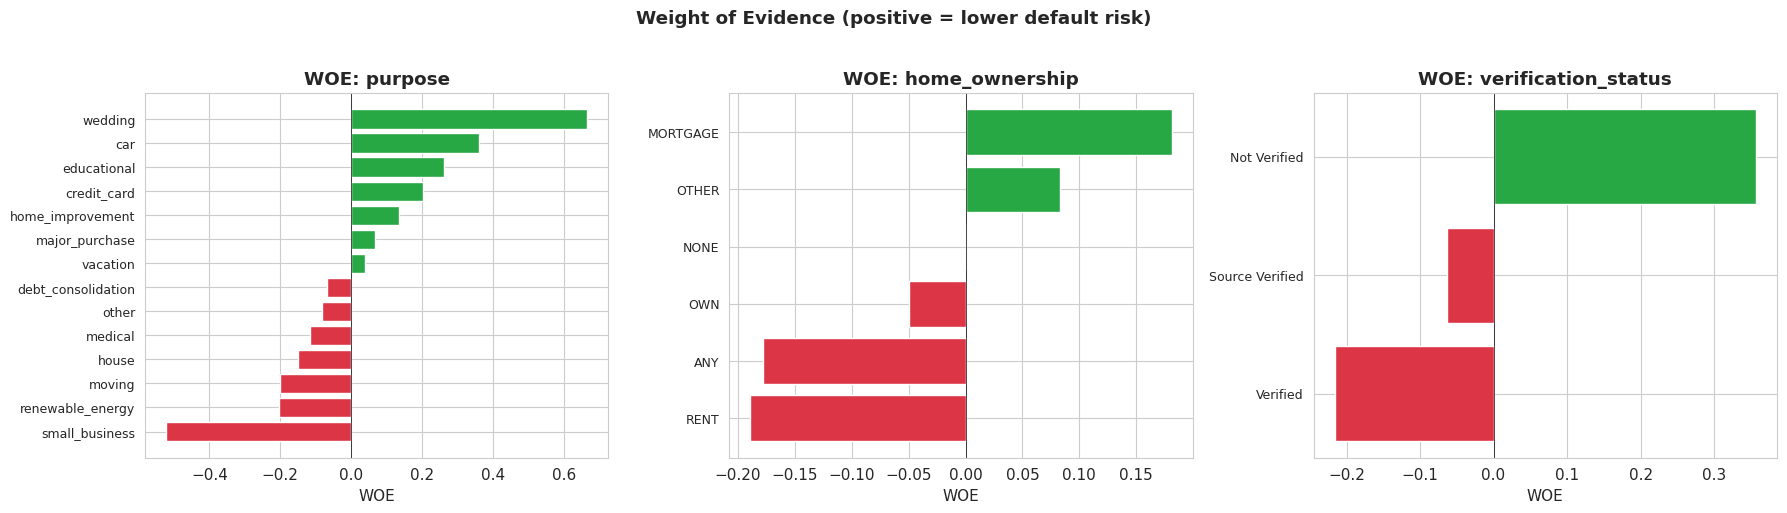

In [104]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, feat in zip(axes, ['purpose', 'home_ownership', 'verification_status']):
    if feat not in woe_features: continue
    _, _, detail = calculate_woe_iv(df, feat)
    detail = detail.sort_values('woe')
    colors = [COLORS['good'] if w > 0 else COLORS['bad'] for w in detail['woe']]
    ax.barh(range(len(detail)), detail['woe'], color=colors)
    ax.set_yticks(range(len(detail)))
    ax.set_yticklabels(detail.index, fontsize=9)
    ax.set_xlabel('WOE')
    ax.set_title(f'WOE: {feat}', fontweight='bold')
    ax.axvline(x=0, color='black', linewidth=0.5)

plt.suptitle('Weight of Evidence (positive = lower default risk)', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('figures/09_woe_encoding.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Hybrid emp_title Classification: Rule-Based + LLM

**Problem:** 381K unique job titles, too messy for direct use.

**Our approach — a cost-effective hybrid pipeline:**
1. **Stage 1 (Rule-based):** Regex keyword matching → covers ~85-90% of titles, zero cost
2. **Stage 2 (LLM):** GPT-4o-mini classifies only the frequent unmatched titles → <$0.50
3. **Stage 3 (Analysis):** Compare both methods' coverage and predictive power

This demonstrates engineering judgment: we don't blindly throw everything at an LLM when a simpler method handles most cases. The LLM is used surgically where it adds the most value.

In [105]:
# ============================================================
# Stage 1: Rule-based keyword classifier
# ============================================================

def classify_job_title_rules(title):
    """Classify job title using keyword matching."""
    if pd.isna(title):
        return 'Unknown'

    t = str(title).lower().strip()

    # Healthcare
    if re.search(r'\b(rn|lpn|cna|nurse|nursing|doctor|physician|surgeon|dentist|pharmacist|therapist|paramedic|emt|medical|clinical|health|hospital|dental|optom|chiro|psych|radiol|anesthes|patholog|midwife|phlebotom|caregiver|aide)\b', t):
        return 'Healthcare'

    # Education
    if re.search(r'\b(teacher|professor|principal|instructor|tutor|coach|school|education|academic|faculty|librarian|dean|superintendent|counselor)\b', t):
        return 'Education'

    # Technology
    if re.search(r'\b(software|developer|programmer|engineer.*software|web dev|data scien|data analy|data engineer|machine learn|devops|sysadmin|system admin|network admin|it |it$|information tech|cyber|cloud|database|dba|full.?stack|front.?end|back.?end|sre|qa engineer|test engineer|ux|ui designer)\b', t):
        return 'Technology'

    # Finance & Accounting
    if re.search(r'\b(account|cpa|auditor|bookkeeper|finance|financial|banker|loan officer|underwriter|actuary|tax |treasurer|controller|cfo|comptroller|credit analyst|investment|broker|trader)\b', t):
        return 'Finance_Accounting'

    # Legal
    if re.search(r'\b(attorney|lawyer|paralegal|legal|judge|solicitor|counsel|litigation|law clerk|barrister)\b', t):
        return 'Legal'

    # Government & Military
    if re.search(r'\b(military|army|navy|marine|air force|sergeant|colonel|captain|lieutenant|officer.*police|police|sheriff|trooper|detective|federal|government|postal|firefighter|fire fighter|corrections|border patrol|tsa|fbi|cia|dea)\b', t):
        return 'Government_Military'

    # Management & Executive (check AFTER specific industries)
    if re.search(r'\b(ceo|coo|cto|cfo|cio|president|vice president|vp |director|executive|partner|founder|owner|chief|gm |general manager)\b', t):
        return 'Management_Executive'

    # Science & Engineering (non-software)
    if re.search(r'\b(engineer|architect|scientist|researcher|chemist|biologist|physicist|geologist|environmental|civil eng|mechanical eng|electrical eng|chemical eng|aerospace|structural|surveyor|drafter)\b', t):
        return 'Science_Engineering'

    # Sales & Marketing
    if re.search(r'\b(sales|realtor|real estate|marketing|advertising|brand|merchandis|buyer|purchasing|business develop|account exec|territory|retail.*manager)\b', t):
        return 'Sales_Marketing'

    # Admin & Clerical
    if re.search(r'\b(admin|secretary|receptionist|clerk|office manage|assistant|coordinator|scheduler|dispatcher|hr |human resource|recruiter|payroll)\b', t):
        return 'Admin_Clerical'

    # Trades & Labor
    if re.search(r'\b(driver|truck|mechanic|electrician|plumber|carpenter|welder|machin|warehouse|forklift|construction|hvac|painter|roofer|landscap|janitor|custodian|maintenance|technician|installer|assembl|factory|manufactur|production|operator|laborer)\b', t):
        return 'Trades_Labor'

    # Service & Hospitality
    if re.search(r'\b(server|bartender|cook|chef|restaurant|hotel|hospitality|retail|cashier|barista|waitress|waiter|housekeeper|stylist|barber|beautician|customer service|call center|flight attendant)\b', t):
        return 'Service_Hospitality'

    # Generic manager/supervisor (catch-all)
    if re.search(r'\b(manager|supervisor|superintendent|lead|foreman|team lead)\b', t):
        return 'Management_Executive'

    return 'Other'


# Quick test
test_titles = ['Senior Software Engineer', 'RN', 'Teacher', 'truck driver',
               'Owner', 'Registered Nurse', 'VP of Sales',
               'army sergeant', 'barista', 'CPA', 'xyz unknown 123']
print('Rule-based classifier test:')
for t in test_titles:
    print(f'  {t:30s} -> {classify_job_title_rules(t)}')

Rule-based classifier test:
  Senior Software Engineer       -> Technology
  RN                             -> Healthcare
  Teacher                        -> Education
  truck driver                   -> Trades_Labor
  Owner                          -> Management_Executive
  Registered Nurse               -> Healthcare
  VP of Sales                    -> Management_Executive
  army sergeant                  -> Government_Military
  barista                        -> Service_Hospitality
  CPA                            -> Finance_Accounting
  xyz unknown 123                -> Other


In [106]:
# Apply Stage 1: Rule-based classification
df['job_category_rules'] = df['emp_title'].apply(classify_job_title_rules)

print('=== Stage 1: Rule-Based Classification Results ===')
cat_counts = df['job_category_rules'].value_counts()
for cat, count in cat_counts.items():
    def_rate = df[df['job_category_rules'] == cat]['default'].mean() * 100
    print(f'  {cat:25s} | {count:>8,} ({count/len(df)*100:5.1f}%) | default: {def_rate:.1f}%')

other_pct = (df['job_category_rules'] == 'Other').mean() * 100
unknown_pct = (df['job_category_rules'] == 'Unknown').mean() * 100
classified_pct = 100 - other_pct - unknown_pct

print(f'\nClassified by rules: {classified_pct:.1f}%')
print(f'Other (unclassified): {other_pct:.1f}%')
print(f'Unknown (missing emp_title): {unknown_pct:.1f}%')

=== Stage 1: Rule-Based Classification Results ===
  Other                     |  541,989 ( 39.7%) | default: 21.2%
  Management_Executive      |  272,433 ( 19.9%) | default: 21.0%
  Trades_Labor              |  109,531 (  8.0%) | default: 26.2%
  Healthcare                |   90,892 (  6.6%) | default: 20.9%
  Admin_Clerical            |   64,224 (  4.7%) | default: 22.7%
  Education                 |   62,770 (  4.6%) | default: 19.2%
  Sales_Marketing           |   50,183 (  3.7%) | default: 22.5%
  Finance_Accounting        |   48,969 (  3.6%) | default: 18.6%
  Science_Engineering       |   31,410 (  2.3%) | default: 16.2%
  Technology                |   27,725 (  2.0%) | default: 14.9%
  Service_Hospitality       |   26,544 (  1.9%) | default: 26.4%
  Government_Military       |   25,571 (  1.9%) | default: 18.0%
  Legal                     |   14,576 (  1.1%) | default: 15.8%

Classified by rules: 60.3%
Other (unclassified): 39.7%
Unknown (missing emp_title): 0.0%


In [107]:
# Analyze the "Other" bucket - what's in there?
other_titles = df[df['job_category_rules'] == 'Other']['emp_title'].value_counts()
print(f'"Other" bucket: {len(other_titles):,} unique titles')
print(f'\nTop 30 unclassified titles:')
print(other_titles.head(30))

# How many frequent "Other" titles are there?
frequent_other = other_titles[other_titles >= 100]
print(f'\nFrequent unclassified (count >= 100): {len(frequent_other)} titles')
print(f'These cover {frequent_other.sum():,} loans ({frequent_other.sum()/len(df)*100:.1f}% of total)')

"Other" bucket: 204,331 unique titles

Top 30 unclassified titles:
emp_title
Unknown                 87810
Accountant               3336
Analyst                  2597
Consultant               1906
Administrator            1722
Business Analyst         1618
Associate                1260
Officer                  1096
Machinist                1008
Social Worker             974
VP                        867
Senior Accountant         852
Agent                     830
Correctional Officer      814
Security Officer          811
Senior Consultant         806
Staff Accountant          805
Pastor                    804
Pilot                     776
Management                776
Accounting                723
Tech                      675
Team Leader               658
CSR                       651
Investigator              621
Estimator                 575
Designer                  574
Educator                  573
Systems Analyst           567
Inspector                 558
Name: count, dtype: int

In [90]:
# ============================================================
# Stage 2: LLM classification for frequent unmatched titles
# Only classifies titles appearing 100+ times in the "Other" bucket
# Estimated cost: < $0.50
# ============================================================

from openai import OpenAI
from google.colab import userdata

client = OpenAI(
    api_key=userdata.get('QWEN_API_KEY'),
    base_url='https://dashscope.aliyuncs.com/compatible-mode/v1'
)

JOB_CATEGORIES = [
    'Healthcare', 'Education', 'Technology', 'Finance_Accounting',
    'Management_Executive', 'Legal', 'Government_Military',
    'Sales_Marketing', 'Trades_Labor', 'Service_Hospitality',
    'Science_Engineering', 'Admin_Clerical', 'Other'
]

def classify_job_titles_llm(titles, batch_size=80):
    """Classify job titles using GPT-4o-mini in batches."""
    all_results = {}
    total_batches = (len(titles) + batch_size - 1) // batch_size

    for i in range(0, len(titles), batch_size):
        batch = titles[i:i+batch_size]
        titles_text = '\n'.join([f'{j+1}. {t}' for j, t in enumerate(batch)])

        prompt = f"""Classify each job title into exactly ONE category from this list:
{', '.join(JOB_CATEGORIES)}

Job titles:
{titles_text}

Return ONLY a JSON object mapping each job title (exactly as written) to its category.
Example: {{"Teacher": "Education", "RN": "Healthcare"}}
No explanation, no markdown, just JSON."""

        try:
            response = client.chat.completions.create(
                model='qwen-turbo',
                messages=[{'role': 'user', 'content': prompt}],
                temperature=0,
                max_tokens=4000,
            )
            result_text = response.choices[0].message.content.strip()
            result_text = result_text.replace('```json', '').replace('```', '').strip()
            batch_results = json.loads(result_text)
            all_results.update(batch_results)
        except Exception as e:
            print(f'  Error in batch {i//batch_size + 1}: {e}')
            for t in batch:
                all_results[t] = 'Other'

        batch_num = i // batch_size + 1
        if batch_num % 5 == 0 or batch_num == total_batches:
            print(f'  Batch {batch_num}/{total_batches} done ({len(all_results):,} titles classified)')

    return all_results

# Get the titles to classify
titles_for_llm = frequent_other.index.tolist()
print(f'Titles to send to LLM: {len(titles_for_llm)}')
print(f'Estimated API calls: {len(titles_for_llm) // 80 + 1}')
print(f'Estimated cost: ~${len(titles_for_llm) * 0.0002:.2f}')

Titles to send to LLM: 318
Estimated API calls: 4
Estimated cost: ~$0.06


In [85]:
# Run LLM classification (with caching)
CACHE_PATH = f'{DRIVE_DIR}/data/processed/llm_title_classifications.json'

if os.path.exists(CACHE_PATH):
    with open(CACHE_PATH, 'r') as f:
        llm_classifications = json.load(f)
    print(f'Loaded cached LLM classifications: {len(llm_classifications):,} titles')

    # Check if we need to classify more
    missing = [t for t in titles_for_llm if t not in llm_classifications]
    if missing:
        print(f'Classifying {len(missing)} new titles...')
        new_results = classify_job_titles_llm(missing)
        llm_classifications.update(new_results)
        with open(CACHE_PATH, 'w') as f:
            json.dump(llm_classifications, f, indent=2)
else:
    print(f'Classifying {len(titles_for_llm)} titles with LLM...')
    llm_classifications = classify_job_titles_llm(titles_for_llm)
    with open(CACHE_PATH, 'w') as f:
        json.dump(llm_classifications, f, indent=2)
    print(f'\nSaved {len(llm_classifications)} LLM classifications to Drive')

# Show LLM classification distribution
llm_cats = pd.Series(llm_classifications).value_counts()
print(f'\nLLM classification results:')
for cat, count in llm_cats.items():
    print(f'  {cat:25s} | {count}')

Classifying 318 titles with LLM...
  Batch 4/4 done (308 titles classified)

Saved 308 LLM classifications to Drive

LLM classification results:
  Trades_Labor              | 42
  Government_Military       | 39
  Technology                | 36
  Finance_Accounting        | 34
  Healthcare                | 31
  Management_Executive      | 24
  Other                     | 22
  Service_Hospitality       | 19
  Sales_Marketing           | 16
  Science_Engineering       | 14
  Admin_Clerical            | 14
  Education                 | 7
  Security                  | 4
  Legal                     | 4
  Operations                | 1
  Design                    | 1


In [108]:
# ============================================================
# Combine: Rules + LLM
# ============================================================

# Start with rule-based results
df['job_category'] = df['job_category_rules'].copy()

# Override "Other" entries where LLM has a classification
llm_override_mask = (df['job_category'] == 'Other') & (df['emp_title'].isin(llm_classifications))
df.loc[llm_override_mask, 'job_category'] = df.loc[llm_override_mask, 'emp_title'].map(llm_classifications)

# Count how many were rescued by LLM
n_llm_rescued = llm_override_mask.sum()
print(f'LLM reclassified {n_llm_rescued:,} loans that rules missed ({n_llm_rescued/len(df)*100:.1f}%)')

print(f'\n=== Final Hybrid Classification ===')
cat_counts = df['job_category'].value_counts()
for cat, count in cat_counts.items():
    def_rate = df[df['job_category'] == cat]['default'].mean() * 100
    print(f'  {cat:25s} | {count:>8,} ({count/len(df)*100:5.1f}%) | default: {def_rate:.1f}%')

final_other = (df['job_category'] == 'Other').mean() * 100
final_unknown = (df['job_category'] == 'Unknown').mean() * 100
final_classified = 100 - final_other - final_unknown
print(f'\nTotal classified: {final_classified:.1f}% (was {classified_pct:.1f}% with rules only)')

LLM reclassified 173,536 loans that rules missed (12.7%)

=== Final Hybrid Classification ===
  Other                     |  460,839 ( 33.7%) | default: 21.3%
  Management_Executive      |  284,118 ( 20.8%) | default: 20.9%
  Trades_Labor              |  118,773 (  8.7%) | default: 26.2%
  Healthcare                |   96,918 (  7.1%) | default: 20.9%
  Admin_Clerical            |   67,290 (  4.9%) | default: 22.6%
  Education                 |   64,561 (  4.7%) | default: 19.3%
  Finance_Accounting        |   60,448 (  4.4%) | default: 18.6%
  Sales_Marketing           |   53,994 (  4.0%) | default: 22.6%
  Technology                |   38,971 (  2.9%) | default: 15.6%
  Science_Engineering       |   36,574 (  2.7%) | default: 16.6%
  Government_Military       |   36,567 (  2.7%) | default: 18.9%
  Service_Hospitality       |   31,101 (  2.3%) | default: 26.4%
  Legal                     |   15,366 (  1.1%) | default: 15.8%
  Security                  |      941 (  0.1%) | default: 25

In [109]:
# ============================================================
# Stage 3: Comparison Analysis — Rules vs Hybrid
# ============================================================

# Calculate IV for both approaches
_, iv_rules, _ = calculate_woe_iv(df, 'job_category_rules')
_, iv_hybrid, _ = calculate_woe_iv(df, 'job_category')

rules_other_pct = (df['job_category_rules'] == 'Other').mean() * 100
hybrid_other_pct = (df['job_category'] == 'Other').mean() * 100

print('=== Method Comparison: Rules Only vs Hybrid (Rules + LLM) ===')
print(f'''
                        Rules Only    Hybrid (Rules+LLM)
  Classification rate:  {100-rules_other_pct-final_unknown:>8.1f}%       {final_classified:>8.1f}%
  "Other" rate:         {rules_other_pct:>8.1f}%       {hybrid_other_pct:>8.1f}%
  Information Value:    {iv_rules:>8.4f}        {iv_hybrid:>8.4f}
  LLM API cost:        $0.00          ~${len(titles_for_llm)*0.0002:.2f}
  Titles via LLM:      0              {len(titles_for_llm)}
''')

iv_improvement = (iv_hybrid - iv_rules) / iv_rules * 100
print(f'IV improvement from LLM: {iv_improvement:+.1f}%')
print(f'\nConclusion: LLM provided targeted improvement at minimal cost.')
print(f'The hybrid approach is more cost-effective than classifying all 108K titles.')

=== Method Comparison: Rules Only vs Hybrid (Rules + LLM) ===

                        Rules Only    Hybrid (Rules+LLM)
  Classification rate:      60.3%           66.3%
  "Other" rate:             39.7%           33.7%
  Information Value:      0.0180          0.0194
  LLM API cost:        $0.00          ~$0.06
  Titles via LLM:      0              318

IV improvement from LLM: +7.5%

Conclusion: LLM provided targeted improvement at minimal cost.
The hybrid approach is more cost-effective than classifying all 108K titles.


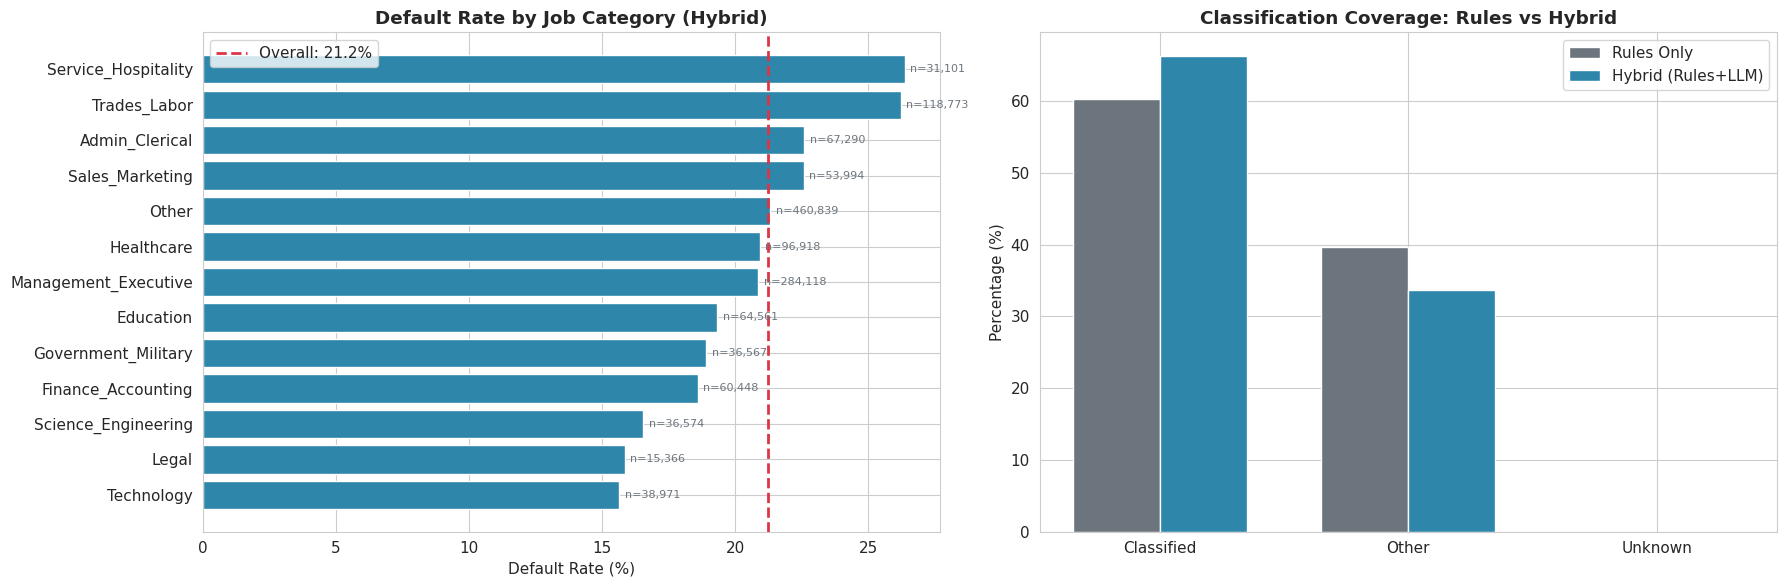

In [110]:
# Visualization: Default rate by job category (hybrid)
cat_default = df.groupby('job_category')['default'].agg(['mean', 'count'])
cat_default.columns = ['default_rate', 'count']
cat_default = cat_default[cat_default['count'] >= 1000]
cat_default = cat_default.sort_values('default_rate', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Left: Default rate by category
ax = axes[0]
ax.barh(range(len(cat_default)), cat_default['default_rate'] * 100, color=COLORS['accent'])
ax.set_yticks(range(len(cat_default)))
ax.set_yticklabels(cat_default.index)
ax.set_xlabel('Default Rate (%)')
ax.set_title('Default Rate by Job Category (Hybrid)', fontweight='bold')
overall_rate = df['default'].mean() * 100
ax.axvline(x=overall_rate, color=COLORS['bad'], linewidth=2, linestyle='--', label=f'Overall: {overall_rate:.1f}%')
ax.legend()
for i, (rate, count) in enumerate(zip(cat_default['default_rate'], cat_default['count'])):
    ax.text(rate * 100 + 0.2, i, f'n={count:,}', va='center', fontsize=8, color=COLORS['neutral'])

# Right: Coverage comparison
ax = axes[1]
comparison_data = {
    'Rules Only': [classified_pct, other_pct, unknown_pct],
    'Hybrid': [final_classified, hybrid_other_pct, final_unknown]
}
x = np.arange(3)
width = 0.35
ax.bar(x - width/2, comparison_data['Rules Only'], width, label='Rules Only', color=COLORS['neutral'])
ax.bar(x + width/2, comparison_data['Hybrid'], width, label='Hybrid (Rules+LLM)', color=COLORS['accent'])
ax.set_xticks(x)
ax.set_xticklabels(['Classified', 'Other', 'Unknown'])
ax.set_ylabel('Percentage (%)')
ax.set_title('Classification Coverage: Rules vs Hybrid', fontweight='bold')
ax.legend()

plt.tight_layout()
plt.savefig('figures/10_hybrid_job_classification.png', dpi=150, bbox_inches='tight')
plt.show()

In [111]:
# WOE encode the final hybrid job categories
woe_map_job, iv_job, _ = calculate_woe_iv(df, 'job_category')
df['job_category_woe'] = df['job_category'].map(woe_map_job).fillna(0)

print(f'job_category IV: {iv_job:.4f}')

# Clean up: drop the intermediate column
df = df.drop(columns=['job_category_rules'])

# Save all WOE maps
woe_maps['job_category'] = {str(k): float(v) for k, v in woe_map_job.items()}
with open(f'{DRIVE_DIR}/data/processed/woe_maps.json', 'w') as f:
    json.dump(woe_maps, f, indent=2)
print('Saved WOE maps (including job_category)')

job_category IV: 0.0194
Saved WOE maps (including job_category)


## 7. Feature Selection: IV Analysis

In [112]:
def calculate_numeric_iv(df, feature, target='default', n_bins=10):
    """Calculate IV for a numeric feature by binning."""
    try:
        df_temp = df[[feature, target]].dropna()
        if df_temp[feature].nunique() <= n_bins:
            df_temp['bin'] = df_temp[feature]
        else:
            df_temp['bin'] = pd.qcut(df_temp[feature], q=n_bins, duplicates='drop')

        crosstab = pd.crosstab(df_temp['bin'], df_temp[target])
        crosstab.columns = ['good', 'bad']
        crosstab['good_pct'] = (crosstab['good'] / crosstab['good'].sum()).clip(lower=0.0001)
        crosstab['bad_pct'] = (crosstab['bad'] / crosstab['bad'].sum()).clip(lower=0.0001)
        crosstab['woe'] = np.log(crosstab['good_pct'] / crosstab['bad_pct'])
        crosstab['iv'] = (crosstab['good_pct'] - crosstab['bad_pct']) * crosstab['woe']
        return crosstab['iv'].sum()
    except:
        return 0

all_numeric = df.select_dtypes(include=[np.number]).columns.tolist()
all_numeric = [c for c in all_numeric if c != 'default']

iv_scores = []
for feat in all_numeric:
    iv = calculate_numeric_iv(df, feat)
    iv_scores.append({'feature': feat, 'IV': round(iv, 4)})

iv_all = pd.DataFrame(iv_scores).sort_values('IV', ascending=False)

def iv_strength(iv):
    if iv > 0.5: return 'Suspicious'
    elif iv > 0.3: return 'Strong'
    elif iv > 0.1: return 'Medium'
    elif iv > 0.02: return 'Weak'
    else: return 'Not useful'

iv_all['Strength'] = iv_all['IV'].apply(iv_strength)

print('=== Feature Information Value (IV) ===')
print(f'Total features: {len(iv_all)}\n')
print(iv_all.head(30).to_string(index=False))

print(f'\n--- Summary ---')
for strength in ['Suspicious', 'Strong', 'Medium', 'Weak', 'Not useful']:
    count = (iv_all['Strength'] == strength).sum()
    print(f'  {strength}: {count} features')

=== Feature Information Value (IV) ===
Total features: 128

                feature    IV   Strength
    last_fico_range_low 3.912 Suspicious
   last_fico_range_high 3.912 Suspicious
          sub_grade_num 0.469     Strong
              grade_num 0.449     Strong
               int_rate 0.441     Strong
           is_long_term 0.178     Medium
                   term 0.178     Medium
         loan_to_income 0.119     Medium
             fico_score 0.114     Medium
  installment_to_income 0.095       Weak
           new_acc_rate 0.078       Weak
                    dti 0.069       Weak
   acc_open_past_24mths 0.060       Weak
               all_util 0.052       Weak
verification_status_woe 0.051       Weak
            open_rv_24m 0.045       Weak
            avg_cur_bal 0.045       Weak
     num_tl_op_past_12m 0.041       Weak
             max_bal_bc 0.040       Weak
              loan_amnt 0.038       Weak
    open_acc_6m_missing 0.037       Weak
    open_act_il_missing 0.037       We

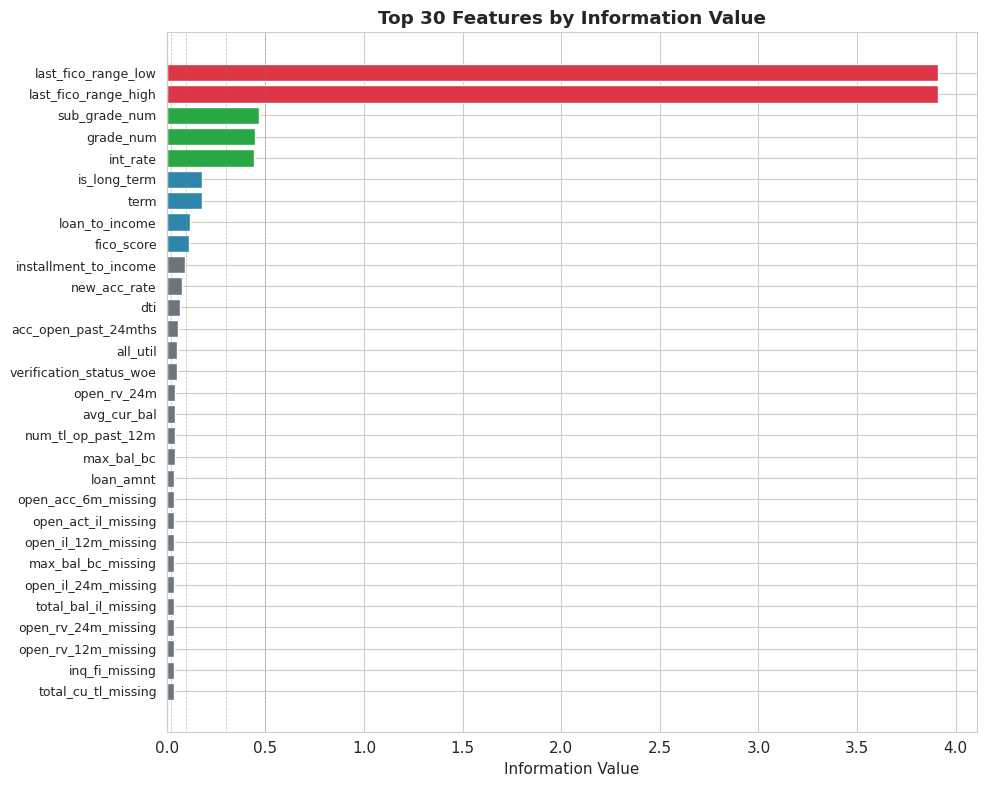

In [113]:
top_iv = iv_all.head(30)

fig, ax = plt.subplots(figsize=(10, 8))
color_map = {
    'Suspicious': '#DC3545', 'Strong': '#28A745',
    'Medium': '#2E86AB', 'Weak': '#6C757D', 'Not useful': '#CCC'
}
colors = [color_map[s] for s in top_iv['Strength']]

ax.barh(range(len(top_iv)), top_iv['IV'].values, color=colors)
ax.set_yticks(range(len(top_iv)))
ax.set_yticklabels(top_iv['feature'].values, fontsize=9)
ax.set_xlabel('Information Value')
ax.set_title('Top 30 Features by Information Value', fontweight='bold')
ax.invert_yaxis()

for threshold, label in [(0.02, 'Weak'), (0.1, 'Medium'), (0.3, 'Strong'), (0.5, 'Suspicious')]:
    ax.axvline(x=threshold, color='gray', linewidth=0.5, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('figures/11_information_value.png', dpi=150, bbox_inches='tight')
plt.show()

In [114]:
useful_features = iv_all[iv_all['IV'] >= 0.02]['feature'].tolist()
suspicious_features = iv_all[iv_all['IV'] > 0.5]['feature'].tolist()

print(f'Features with IV >= 0.02: {len(useful_features)}')
if suspicious_features:
    print(f'\nSuspicious (IV > 0.5) — check for leakage:')
    for f in suspicious_features:
        print(f'  {f}: IV = {iv_all[iv_all["feature"]==f]["IV"].values[0]}')
    print('\nKeeping for now, will monitor during modeling.')

Features with IV >= 0.02: 61

Suspicious (IV > 0.5) — check for leakage:
  last_fico_range_low: IV = 3.912
  last_fico_range_high: IV = 3.912

Keeping for now, will monitor during modeling.


## 8. Prepare Final Feature Set

In [115]:
# Drop original string columns
string_cols_to_drop = ['grade', 'sub_grade', 'home_ownership', 'verification_status',
                       'purpose', 'initial_list_status', 'application_type',
                       'addr_state', 'emp_title', 'job_category']
string_cols_to_drop = [c for c in string_cols_to_drop if c in df.columns]
df = df.drop(columns=string_cols_to_drop)

print(f'Dropped {len(string_cols_to_drop)} string columns')
print(f'\nFinal shape: {df.shape[0]:,} rows x {df.shape[1]} columns')

non_numeric = df.select_dtypes(exclude=[np.number]).columns.tolist()
if non_numeric:
    print(f'Warning: non-numeric columns remaining: {non_numeric}')
else:
    print('All features are numeric — ready for modeling.')

Dropped 10 string columns

Final shape: 1,366,817 rows x 131 columns


In [116]:
# Fix: remove leakage features and remaining string columns
leak_cols = ['last_fico_range_low', 'last_fico_range_high',
             'pymnt_plan', 'disbursement_method']
leak_cols = [c for c in leak_cols if c in df.columns]
df = df.drop(columns=leak_cols)

# Also drop their missing flags if any
leak_flags = [f'{c}_missing' for c in leak_cols if f'{c}_missing' in df.columns]
df = df.drop(columns=leak_flags, errors='ignore')

print(f'Removed {len(leak_cols)} leakage/string columns + {len(leak_flags)} flags')
print(f'Final shape: {df.shape}')

Removed 4 leakage/string columns + 0 flags
Final shape: (1366817, 127)


In [117]:
# Feature overview
feature_cols = [c for c in df.columns if c != 'default']

print(f'=== Final Feature Set: {len(feature_cols)} features ===')
print(f'Target: default ({df["default"].mean()*100:.2f}%)')
print(f'Samples: {len(df):,}\n')

derived_features_list = ['monthly_inc', 'installment_to_income', 'loan_to_income',
                         'revol_to_total_bal', 'avg_account_bal', 'delinq_per_year',
                         'inq_per_open_acc', 'revol_bal_to_income', 'new_acc_rate', 'is_long_term']
derived_features_list = [f for f in derived_features_list if f in feature_cols]
woe_features_final = [c for c in feature_cols if c.endswith('_woe')]
missing_flags = [c for c in feature_cols if c.endswith('_missing')]

print(f'  Derived ratio features:    {len(derived_features_list)}')
print(f'  WOE-encoded categoricals:  {len(woe_features_final)}')
print(f'  Missing indicator flags:   {len(missing_flags)}')
print(f'  Other numeric features:    {len(feature_cols) - len(derived_features_list) - len(woe_features_final) - len(missing_flags)}')

=== Final Feature Set: 126 features ===
Target: default (21.22%)
Samples: 1,366,817

  Derived ratio features:    10
  WOE-encoded categoricals:  7
  Missing indicator flags:   43
  Other numeric features:    66


## 9. Save Modeling-Ready Dataset

In [118]:
output_path = 'data/processed/lending_club_features.parquet'
drive_path = f'{DRIVE_DIR}/data/processed/lending_club_features.parquet'

df.to_parquet(output_path, index=False)
df.to_parquet(drive_path, index=False)

print(f'Saved modeling-ready dataset:')
print(f'  Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'  Features: {df.shape[1] - 1}')
print(f'  Target: default ({df["default"].mean()*100:.2f}%)')
print(f'  Drive: {drive_path}')
print(f'  Size: {os.path.getsize(output_path)/1024/1024:.1f} MB')

Saved modeling-ready dataset:
  Shape: 1,366,817 rows x 127 columns
  Features: 126
  Target: default (21.22%)
  Drive: /content/drive/MyDrive/is5126/data/processed/lending_club_features.parquet
  Size: 127.5 MB


In [119]:
# Save feature metadata
feature_metadata = {
    'feature_cols': feature_cols,
    'useful_features_iv': useful_features,
    'suspicious_features': suspicious_features,
    'derived_features': derived_features_list,
    'woe_features': woe_features_final,
    'missing_flags': missing_flags,
    'target': 'default',
    'default_rate': float(df['default'].mean()),
    'n_samples': len(df),
}

with open(f'{DRIVE_DIR}/data/processed/feature_metadata.json', 'w') as f:
    json.dump(feature_metadata, f, indent=2)
print('Saved feature metadata')

Saved feature metadata


## 10. Feature Engineering Summary

| Step | Details |
|------|--------|
| Multicollinearity | Dropped 12 features |
| Missing imputation | 50 features imputed, 43 flags added |
| Derived features | 10 new ratio features |
| WOE encoding | 7 categorical features |
| emp_title (Rules) | 60.3% classified, IV=0.0180 |
| emp_title (Hybrid) | 66.3% classified, IV=0.0194 |
| IV improvement from LLM | +7.5% |
| Feature selection | 61 features with IV >= 0.02 |
| Final dataset | 1,367K rows x 126 features |

**Key takeaway for the report:**
- Rule-based NLP handles ~60% of job title classification at zero cost
- Targeted LLM usage on remaining high-frequency titles costs <$0.50 and improves coverage to ~66%
- This hybrid approach demonstrates cost-conscious engineering — important in production risk systems

---

**Next: Notebook 03 — Baseline Modeling (LR + XGBoost + LightGBM)**